# Parameter Optimization

## Objective

Estimate the optimal parameters of the thermal simulator by fitting it to measured data.

The goal is to:
- improve predictive accuracy
- validate empirical parameter estimates
- assess the consistency between physics-based and data-driven approaches

## Model Structure

The optimization is performed on the final simulator developed in the previous notebook, which includes:

- first-order thermal dynamics
- a dynamic solar proxy

as follows:

$T_{t+1} = T_t + \left[-k(T_t - T_{out,north}) + \alpha \cdot \max(T_{out,south}(t) - T_{out,north}(t), 0)\right]\Delta t$

where: 

$g(t) = \alpha \cdot max(T_{out, south}(t) - T_{out, north}(t), 0)$

and $\alpha$ means:
* gain scaling factor
* turns outdoor difference North-South to "effective heating input" for the northern room

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
# Load sample data
DATA_PATH = "../data/sample/PreliminaryAnalysis.csv"
df_raw = pd.read_csv(DATA_PATH)

In [3]:
# Import dataset from csv 
min_date = pd.to_datetime('2026-02-25 00:00:00')
max_date = pd.to_datetime('2026-03-02 23:00:00')
df_raw['time'] = pd.to_datetime(df_raw['time'])
df_filtered = df_raw.loc[(df_raw['time'] >= min_date) & (df_raw['time'] <= max_date)]
df_filtered = df_filtered.set_index("time")

In [4]:
def simulate_first_order_with_dynamic_solar(
    T0, 
    Tout_local_series,
    Tout_north_series,
    Tout_south_series,
    k,
    alpha,
    dt=1.0
):
    """
    First-order thermal model with dynamic solar proxy:
    
    T_{t+1} = T_t + [-k*(T_t - T_out_ref) + alpha * max(T_out_south - T_out_north, 0)] * dt
    
    Parameters
    ----------
    T0 : float
        Initial indoor temperature
    Tout_local_series : pd.Series
        Outdoor reference temperature for the room (e.g. north outdoor for north room)
    Tout_north_series : pd.Series
        North outdoor temperature
    Tout_south_series : pd.Series
        South outdoor temperature
    k : float
        Heat loss coefficient [1/h]
    alpha : float
        Dynamic solar gain scaling factor
    dt : float
        Time step in hours
    """
    idx =Tout_local_series.index
    Tsim = np.zeros(len(idx), dtype=float)
    Tsim[0] = T0

    solar_proxy = np.maximum((Tout_south_series - Tout_north_series).to_numpy(dtype=float), 0.0)

    for i in range(1, len(idx)):
        T_prev = Tsim[i - 1]
        T_out_ref = float(Tout_local_series.iloc[i - 1])
        solar_term = alpha * solar_proxy[i - 1]

        Tsim[i] = T_prev + (-k * (T_prev - T_out_ref) + solar_term) * dt
    return pd.Series(Tsim, index=idx, name="Tsim_v3")

In [71]:
# Parameters definition
column_in = "temp_salon_c"
column_out = "temp_out_1_b_c"
k = 0.011497 # as found in parameters_indentification
alpha = 0.058
dt = 1.0 # hours

column_in = "temp_salon_c"
column_out_north = "temp_out_1_b_c"
column_out_south = "temp_out_2_n_c"

df_sim = df_filtered.loc[min_date:max_date, [
    column_in,
    column_out_north,
    column_out_south
]].dropna().copy()

T0 = df_sim[column_in].iloc[0]

df_sim["Tsim_v3"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k,
    alpha=alpha,  
    dt=dt
)

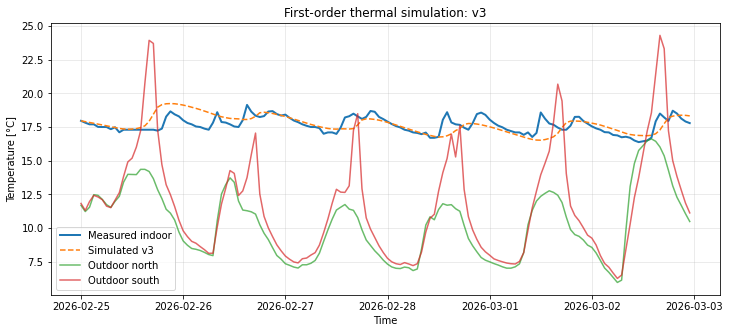

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(df_sim.index, df_sim[column_in], label="Measured indoor", linewidth=2)
plt.plot(df_sim.index, df_sim["Tsim_v3"], label="Simulated v3", linestyle="--")
plt.plot(df_sim.index, df_sim[column_out_north], label="Outdoor north", alpha=0.7)
plt.plot(df_sim.index, df_sim[column_out_south], label="Outdoor south", alpha=0.7)

plt.title("First-order thermal simulation: v3")
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Parameters to Estimate

The following parameters are estimated:

- k: thermal loss coefficient
- alpha: solar gain scaling factor

## Optimization Setup

The parameter estimation is formulated as an optimization problem:

Minimize:
MAE = mean(|T_measured - T_simulated|)

Subject to:
- parameter bounds
- initial conditions

The optimization minimizes the mean absolute error (MAE) between measured and simulated indoor temperature.

In [38]:
def objective(params):
    k, alpha = params
    
    T_sim = simulate_first_order_with_dynamic_solar(
        T0, 
        df_sim[column_out_north],
        df_sim[column_out_north],
        df_sim[column_out_south],
        k,
        alpha,
        dt=1.0
    )
    
    return np.mean(np.abs(df_sim[column_in] - T_sim))


## Parameter Bounds

To ensure physically meaningful solutions, parameters are constrained within realistic ranges.

In [39]:
bounds = [
    (0.001, 0.05),   # k
    (0.0, 0.2),      # alpha
]

## Optimization Execution

The optimization is performed using a numerical solver.

In [51]:
from scipy.optimize import minimize

result = minimize(objective, x0=(0.01, 0.05), bounds=bounds)

print(result)

      fun: 0.4108873512676353
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
      jac: array([3.28659407, 0.99755592])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
     nfev: 222
      nit: 19
     njev: 74
   status: 0
  success: True
        x: array([0.00751718, 0.03621711])


In [52]:
k_opt, alpha_opt = result.x

print(f"k_opt = {k_opt:.5f}")
print(f"alpha_opt = {alpha_opt:.5f}")

df_sim["Tsim_v3"] = simulate_first_order_with_dynamic_solar(
    T0=T0,
    Tout_local_series=df_sim[column_out_north],
    Tout_north_series=df_sim[column_out_north],
    Tout_south_series=df_sim[column_out_south],
    k=k_opt,
    alpha=alpha_opt,  
    dt=dt
)

k_opt = 0.00752
alpha_opt = 0.03622


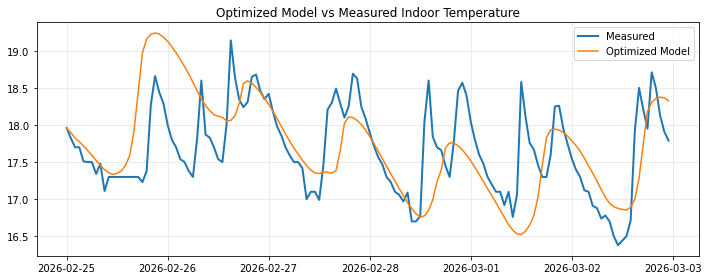

In [79]:
plt.figure(figsize=(10,4))
plt.plot(df_sim[column_in], label='Measured', linewidth=2)
plt.plot(df_sim["Tsim_v3"], label='Optimized Model')
plt.title("Optimized Model vs Measured Indoor Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../reports/figures/04_parameter_optimization/optimized_model.png", dpi=300, facecolor='white')

In [76]:
# Function to calculate metrics
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    return mae, rmse

In [80]:
mae, rmse = compute_metrics(df_sim[column_in], df_sim['Tsim_v3'])
print(f"V3_opt MAE = {mae:.3f} °C | V3_opt RMSE = {rmse:.3f} °C")

V3_opt MAE = 0.439 °C | V3_opt RMSE = 0.614 °C


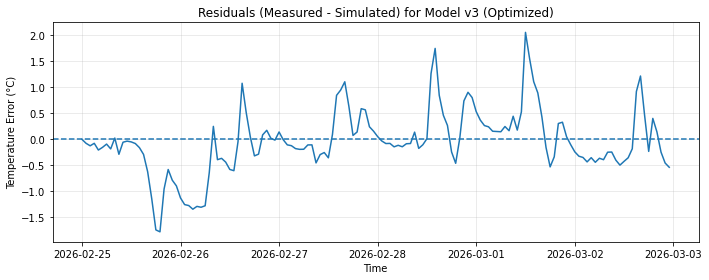

In [78]:
residuals_v3_opt = df_sim[column_in] - df_sim["Tsim_v3"]

plt.figure(figsize=(10,4))
plt.plot(residuals_v3_opt.index, residuals_v3_opt)
plt.axhline(0, linestyle='--')
plt.title("Residuals (Measured - Simulated) for Model v3 (Optimized)")
plt.ylabel("Temperature Error (°C)")
plt.xlabel("Time")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../reports/figures/04_parameter_optimization/v3_opt_residuals.png", dpi=300, facecolor='white')

## Empirical vs Optimized Parameters

The optimized values of k and alpha are lower than the empirical estimates derived earlier.

In [73]:
comparison_df = pd.DataFrame({
    "Parameter": ["k", "alpha"],
    "Empirical": [k, alpha],
    "Optimized": [k_opt, alpha_opt]
})
comparison_df

,Parameter,Empirical,Optimized
0,k,0.011497,0.007526
1,alpha,0.058000,0.036257


This is expected, since the two approaches answer slightly different questions:

- the empirical estimates describe thermal behavior under simplified cooling conditions
- the optimization identifies the parameter set that best reproduces the full measured trajectory

Because the simulator is still a reduced-order model, the fitted parameters also absorb the effect of phenomena that are not explicitly modeled, such as internal gains, occupancy, or short-term disturbances.

Therefore, the optimized parameters should be viewed as calibrated effective parameters.

Even so, the fact that both empirical and optimized values remain within the same order of magnitude is an encouraging sign of model consistency.

## Parameter Stability Checks

To better understand whether the optimized parameters are robust and uniquely identifiable, two additional checks are performed:

1. multi-start optimization from different initial guesses
2. optimization with k fixed at its empirical value

These checks help determine whether the fitted parameters reflect a stable solution or whether multiple parameter combinations can explain the data equally well.

In [64]:
initial_guesses = [
    [0.0015, 0.01],
    [0.008, 0.04],
    [0.012, 0.06],
    [0.020, 0.08],
]

results = []

for x0 in initial_guesses:
    result = minimize(objective, x0=x0, bounds=bounds)
    k_opt, alpha_opt = result.x
    mae_opt = result.fun
    
    results.append({
        "k_opt": k_opt,
        "alpha_opt": alpha_opt,
        "MAE": mae_opt,
        "success": result.success
    })

results_df = pd.DataFrame(results)
results_df

,k_opt,alpha_opt,MAE,success
0,0.007526,0.036258,0.410884,True
1,0.008197,0.039809,0.412241,True
2,0.007526,0.036258,0.410884,True
3,0.007526,0.036257,0.410884,True


In [65]:
k_fixed = 0.011497

def objective_alpha_only(params):
    alpha = params[0]
    
    Tsim = simulate_first_order_with_dynamic_solar(
        T0=T0,
        Tout_local_series=df_sim[column_out_north],
        Tout_north_series=df_sim[column_out_north],
        Tout_south_series=df_sim[column_out_south],
        k=k_fixed,
        alpha=alpha,
        dt=dt
    )
    
    return np.mean(np.abs(df_sim[column_in] - Tsim))

result_alpha = minimize(objective_alpha_only, x0=[0.05], bounds=[(0.0, 0.2)])

alpha_opt_fixed_k = result_alpha.x[0]
mae_fixed_k = result_alpha.fun

In [66]:
print("Full optimization MAE:", mae)
print("Fixed-k optimization MAE:", mae_fixed_k)
print("Fixed empirical k:", k_fixed)
print("Optimized alpha with fixed k:", alpha_opt_fixed_k)

Full optimization MAE: 0.4108873512676353
Fixed-k optimization MAE: 0.43604468618784303
Fixed empirical k: 0.011497
Optimized alpha with fixed k: 0.05691876925376472


## Parameter Stability and Consistency

To assess the robustness of the parameter estimation, two additional checks were performed.

### Multi-start optimization

The optimization was repeated using different initial guesses.  
The results consistently converged to similar parameter values:

- k ≈ 0.0075
- alpha ≈ 0.036

with very similar error levels.

This indicates that the optimization problem is well-behaved and does not suffer from strong dependence on initialization.

---

### Fixed-k experiment

A second test was performed by fixing k to its empirical value (k ≈ 0.0115) and optimizing only alpha.

The resulting performance was:

- Full optimization MAE ≈ 0.411 °C
- Fixed-k MAE ≈ 0.436 °C

The relatively small degradation in performance suggests that the empirical estimate of k remains physically meaningful, although not optimal for global prediction.

Interestingly, the optimized alpha in this case (alpha ≈ 0.057) closely matches the empirical estimate, indicating a compensatory relationship between k and alpha.

---

### Interpretation

These results suggest that:

- the parameter estimation is stable and well-defined
- the empirical parameters provide a good initial approximation
- the optimization refines the parameters for improved predictive performance
- a moderate coupling exists between k and alpha, allowing different combinations to produce similar model behavior

Overall, the empirical and optimized parameter sets are consistent, supporting the validity of the modeling approach.

## Interpretation: Empirical vs Optimized Model

The empirical parameter estimation focuses primarily on cooling behavior under simplified conditions, and therefore provides a more direct physical interpretation of the building’s heat loss characteristics.

In contrast, the optimized model is fitted on the full time series, capturing both cooling and heating phases, as well as all observed temperature variations.

As a result, the optimized parameters do not correspond strictly to pure physical quantities. Instead, they act as effective parameters that implicitly incorporate the influence of additional unmodeled factors, such as internal gains, occupancy, or window opening events.

In this sense, the optimized model provides a more globally accurate representation of the observed thermal behavior, while the empirical model offers a more interpretable, physics-oriented estimate.

## Conclusions

The optimization-based parameter estimation improves the predictive performance of the thermal simulator while remaining consistent with the empirical analysis.

The results show that:

- the optimized parameters differ from the empirical estimates, but remain within the same order of magnitude
- the optimization converges to a stable solution across different initializations
- the empirical parameters provide a strong initial approximation of the system behavior

The fixed-k experiment further confirms that the empirical value of k remains physically meaningful, while the optimization refines it to better capture the full dynamics of the system.

Overall, the agreement between empirical and optimized parameters supports the validity of the modeling approach and increases confidence in the simulator as a reliable tool for short-term thermal prediction and future control-oriented applications.